# Hierarchical Bradley--Terry Models: NRL Analysis

## Init

In [1]:
# This block is needed to treat our code like a package (for now)
# When it's set up properly later, this will be unnecessary

import os
import sys

root_dir = os.path.dirname(os.path.abspath(os.curdir))
src_dir = os.path.join(root_dir, 'src')
sys.path.append(src_dir)
# print(sys.path[-1])

In [2]:
import numpy as np
from numpy import ndarray, exp, log
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
import seaborn as sns

# Our models and things
from DynamicModel import *
from hypothesis_tests import *
from utils import *
from visualisation import *

# To format the AFL data for use in our models
from data_utils_afl import *

rng = np.random.default_rng(0)
sns.set_theme(style="darkgrid")

## Data loading and EDA

We first need to load the data.

Match data is sourced from Mitchell Lohmann via [Kaggle](https://www.kaggle.com/datasets/mitchelllohmann/nrl-fixtures-1990-2025) which itself is sourced from [the NRL draw website](https://www.nrl.com/draw).
Venue and tenant data was manually compiled from a few sources: [Austadiums](https://www.austadiums.com/sport/comp/nrl/teams) and [Wikipedia](https://en.wikipedia.org/wiki/National_Rugby_League).
Note that some teams have commercial deals in place to play certain games at some venue, but we do not consider these venues as home grounds for those teams.

Note: we consider a match *neutral* if the given venue is the home ground of neither team (no HGA) OR both teams (neutralised HGA).

### Loading

In [3]:
# Throw together the NRL data from Lohmann's dataset

# path = "../data/nrl/NRL-Fixtures-1990-2025.csv"
# df = pd.read_csv(path)

# df2 = df[(df.Season >= 2003) & (df.Season <= 2025)].sort_values(["Season", "Round"])
# df2.shape

# df_new = DataFrame()
# df_new["home"] = df2.HomeTeam
# df_new["away"] = df2.AwayTeam
# df_new["home_score"] = df2.HomeScore
# df_new["away_score"] = df2.AwayScore
# df_new["is_neutral"] = 0
# df_new["year"] = df2.Season
# df_new["venue"] = df2.Venue
# df_new.reset_index(inplace=True, drop=True)

# df_new.to_csv("../data/nrl/nrl_matches_clean.csv", index=False)

In [4]:
# Get tenants information for checking neutral venues
tenants_path = "../data/nrl/nrl_tenants.csv"
tenants = pd.read_csv(tenants_path)
tenants.end_year = tenants.end_year.fillna(2026).astype("int64")    # Fill empty end years with 2026
tenants = tenants[tenants.deal == 0]                                # We do NOT consider commercial deals as home games

In [5]:
# Get team location information for later
team_path = "../data/nrl/nrl_teams.csv"
team_locations = pd.read_csv(team_path, index_col=0)

In [6]:
# Load the pre-cleaned df
path = "../data/nrl/nrl_matches_clean.csv"
df = pd.read_csv(path)

In [7]:
df.head(20)

,home,away,home_score,away_score,is_neutral,year,venue
0,Bulldogs,Dragons,46.0,28.0,0,2005,ANZ Stadium
1,Wests Tigers,Eels,12.0,28.0,0,2005,ANZ Stadium
2,Sharks,Panthers,20.0,14.0,0,2005,PointsBet Stadium
3,Roosters,Rabbitohs,24.0,12.0,0,2005,Allianz Stadium
4,Warriors,Sea Eagles,20.0,26.0,0,2005,Mt Smart Stadium
5,Storm,Knights,48.0,10.0,0,2005,Olympic Park
6,Broncos,Cowboys,29.0,16.0,0,2005,Suncorp Stadium
7,Cowboys,Bulldogs,24.0,12.0,0,2005,1300SMILES Stadium
8,Raiders,Knights,39.0,14.0,0,2005,Canberra Stadium
9,Dragons,Storm,12.0,46.0,0,2005,WIN Stadium


### EDA (optional)

The data has been loaded successfully. Let's look at some interesting facts while checking everything is as expected.

In [8]:
start = df.year.min()
end = df.year.max()
print(f"Total games played ({start}-{end}): {df.shape[0]}")

Total games played (2005-2024): 3988


In [9]:
print("Number of games played per team")
(df.home.value_counts() + df.away.value_counts()).sort_values(ascending=False)

Number of games played per team


home
Storm           525
Roosters        509
Sea Eagles      507
Broncos         506
Cowboys         504
Panthers        502
Rabbitohs       501
Sharks          499
Eels            498
Raiders         494
Bulldogs        494
Dragons         492
Warriors        490
Knights         488
Wests Tigers    485
Titans          434
Dolphins         48
Name: count, dtype: int64

In [10]:
print("Number of games played per season")
df.year.value_counts().sort_index()

Number of games played per season


year
2005    189
2006    189
2007    201
2008    201
2009    201
2010    201
2011    201
2012    201
2013    201
2014    201
2015    201
2016    201
2017    201
2018    201
2019    201
2020    169
2021    201
2022    201
2023    213
2024    213
Name: count, dtype: int64

In [11]:
print("Number of games played per venue (top 20)")
df.value_counts("venue").sort_values(ascending=False).head(20)

Number of games played per venue (top 20)


venue
Suncorp Stadium              345
ANZ Stadium                  262
Allianz Stadium              251
McDonald Jones Stadium       237
Accor Stadium                233
Cbus Super Stadium           210
PointsBet Stadium            205
1300SMILES Stadium           186
AAMI Park                    169
GIO Stadium                  135
Panthers Stadium             119
CommBank Stadium             117
Mt Smart Stadium             114
Netstrata Jubilee Stadium    113
Lottoland                    110
WIN Stadium                  108
Bankwest Stadium             103
Canberra Stadium              98
BlueBet Stadium               93
4 Pines Park                  92
Name: count, dtype: int64

In [12]:
print("Number of non-neutral and neutral games")
df.is_neutral.value_counts()

Number of non-neutral and neutral games


is_neutral
0    3988
Name: count, dtype: int64

In [13]:
n_ties = len(df[df.home_score == df.away_score])
print(f"Number of tied games ({start}-{end}): {n_ties}")
print(f"This is only {n_ties/len(df):.2%} of the total games!")

Number of tied games (2005-2024): 16
This is only 0.40% of the total games!


In [14]:
# An example look at games between two teams over the years
team1, team2 = "Broncos", "Raiders"
df[((df.home == team1) & (df.away == team2)) | ((df.home == team2) & (df.away == team1))].sort_values(["is_neutral", "venue", "year"])

,home,away,home_score,away_score,is_neutral,year,venue
91,Raiders,Broncos,12.0,20.0,0,2005,Canberra Stadium
338,Raiders,Broncos,30.0,18.0,0,2006,Canberra Stadium
675,Raiders,Broncos,34.0,16.0,0,2008,Canberra Stadium
926,Raiders,Broncos,56.0,0.0,0,2009,Canberra Stadium
996,Raiders,Broncos,22.0,14.0,0,2010,Canberra Stadium
1191,Raiders,Broncos,4.0,20.0,0,2011,Canberra Stadium
1540,Raiders,Broncos,28.0,12.0,0,2012,Canberra Stadium
1682,Raiders,Broncos,30.0,18.0,0,2013,GIO Stadium
1883,Raiders,Broncos,4.0,28.0,0,2014,GIO Stadium
2072,Raiders,Broncos,12.0,24.0,0,2015,GIO Stadium


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3988 entries, 0 to 3987
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   home        3988 non-null   str    
 1   away        3988 non-null   str    
 2   home_score  3988 non-null   float64
 3   away_score  3988 non-null   float64
 4   is_neutral  3988 non-null   int64  
 5   year        3988 non-null   int64  
 6   venue       3988 non-null   str    
dtypes: float64(2), int64(2), str(3)
memory usage: 218.2 KB


### Converting to win matrices

The data needs to be converted into win matrices for the models.

In [16]:
dummy = df.drop("venue", axis=1)
df_van = make_time_blocked_win_matrix(dummy.drop("is_neutral", axis=1))
df_cha = make_time_blocked_venue_win_matrices(dummy)

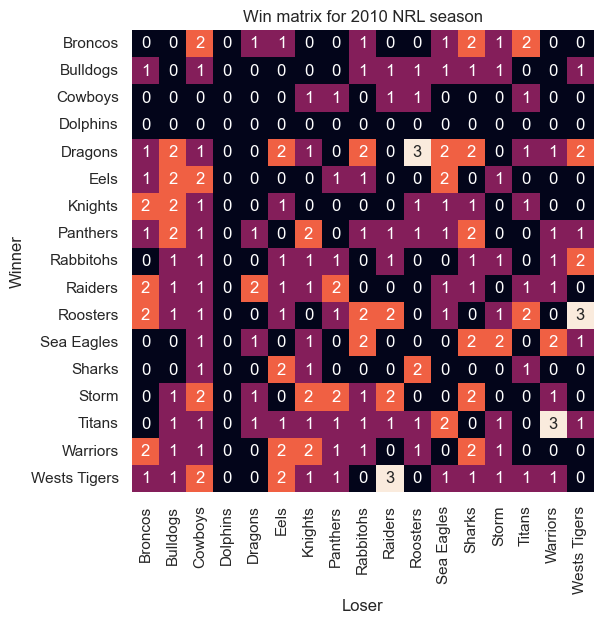

In [17]:
# example_year = [i for i in df_van.keys()][-1]
example_year = 2010
plt.figure(figsize=(6,6))
sns.heatmap(df_van[example_year], annot=True, fmt="g", cbar=False, square=True)
plt.xlabel("Loser")
# plt.xticks(rotation=60, ha="right")
plt.ylabel("Winner")
plt.title(f"Win matrix for {example_year} NRL season")
plt.show()

In [18]:
start, end = 2005, 2024
basic_van = {i: df_van[i] for i in range(start, end+1)}
basic_hga = {i: df_cha[i] for i in range(start, end+1)}

## Basic model fitting

In [19]:
van = VANBT().fit(basic_van)
cha = CHABT().fit(basic_hga)
tsa = TSABT().fit(basic_hga)

Ideally, the models all fit successfully!
At time of writing, the optimisation of the code is not at the standard I'd like, so fitting might be slow.
Regardless, we can check a few things of interest, such as the metadata and fit summaries of each model.
It's also possible to choose which team should be the constraint, such as the estimated worst on average or first alphabetically.

In [20]:
models = (van, cha, tsa)
for model in models: model.summary(verbose=2, wrap_len=135)

MODEL SUMMARY: VANBT

Model Statistics
-------------------------
# Teams:   17              # Obs:     3988
# Times:   20              # Params:  300
LLH:       -2312.334
AIC:       5224.667
BIC:       7111.981
# Iter:    45

Constraint team: Broncos

Team Rankings
-------------------------
                  2005  [SE_2005]      2006  [SE_2006]      2007  [SE_2007]      2008  [SE_2008]      2009  [SE_2009]      2010  \
Storm           -0.200      0.541     0.948      0.614     2.227      0.735     0.503      0.576     0.186      0.553     0.440   
Panthers        -0.508      0.572    -0.942      0.594    -0.598      0.594    -0.592      0.583    -0.502      0.574     0.466   
Roosters        -0.552      0.564    -1.327      0.611    -0.068      0.597    -0.028      0.569    -1.861      0.661     0.706   
Sea Eagles      -0.440      0.557    -0.416      0.566     1.291      0.615     0.792      0.608    -0.181      0.581     0.173   
Broncos          0.000        NaN     0.000        Na

In [21]:
# Interpret the common HGA parameter
np.exp(cha._calculate_odds(0,0,cha._get_hga_param()))
cha._calculate_prob(0,0,cha._get_hga_param())

np.float64(0.5860808168534063)

In [22]:
(df.home_score > df.away_score).mean()

np.float64(0.570962888665998)

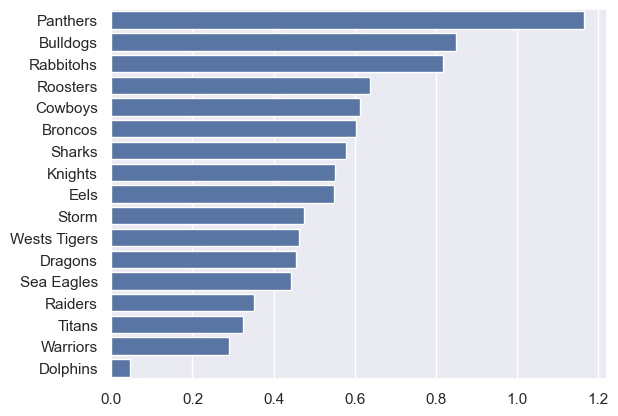

In [23]:
ranking = van.get_ranking("Average", include_errors=False, mean_center=True, as_ranks=False).round(3)
sns.barplot(ranking.drop("Average", axis=1).var(axis=1).sort_values(ascending=False), orient="y")
plt.show()
# (ranking.max() - ranking.min()).sort_values(ascending=False)
# ranking

In [24]:
ranking.drop("Average", axis=1).var(axis=1).mean()

np.float64(0.5415823244541573)

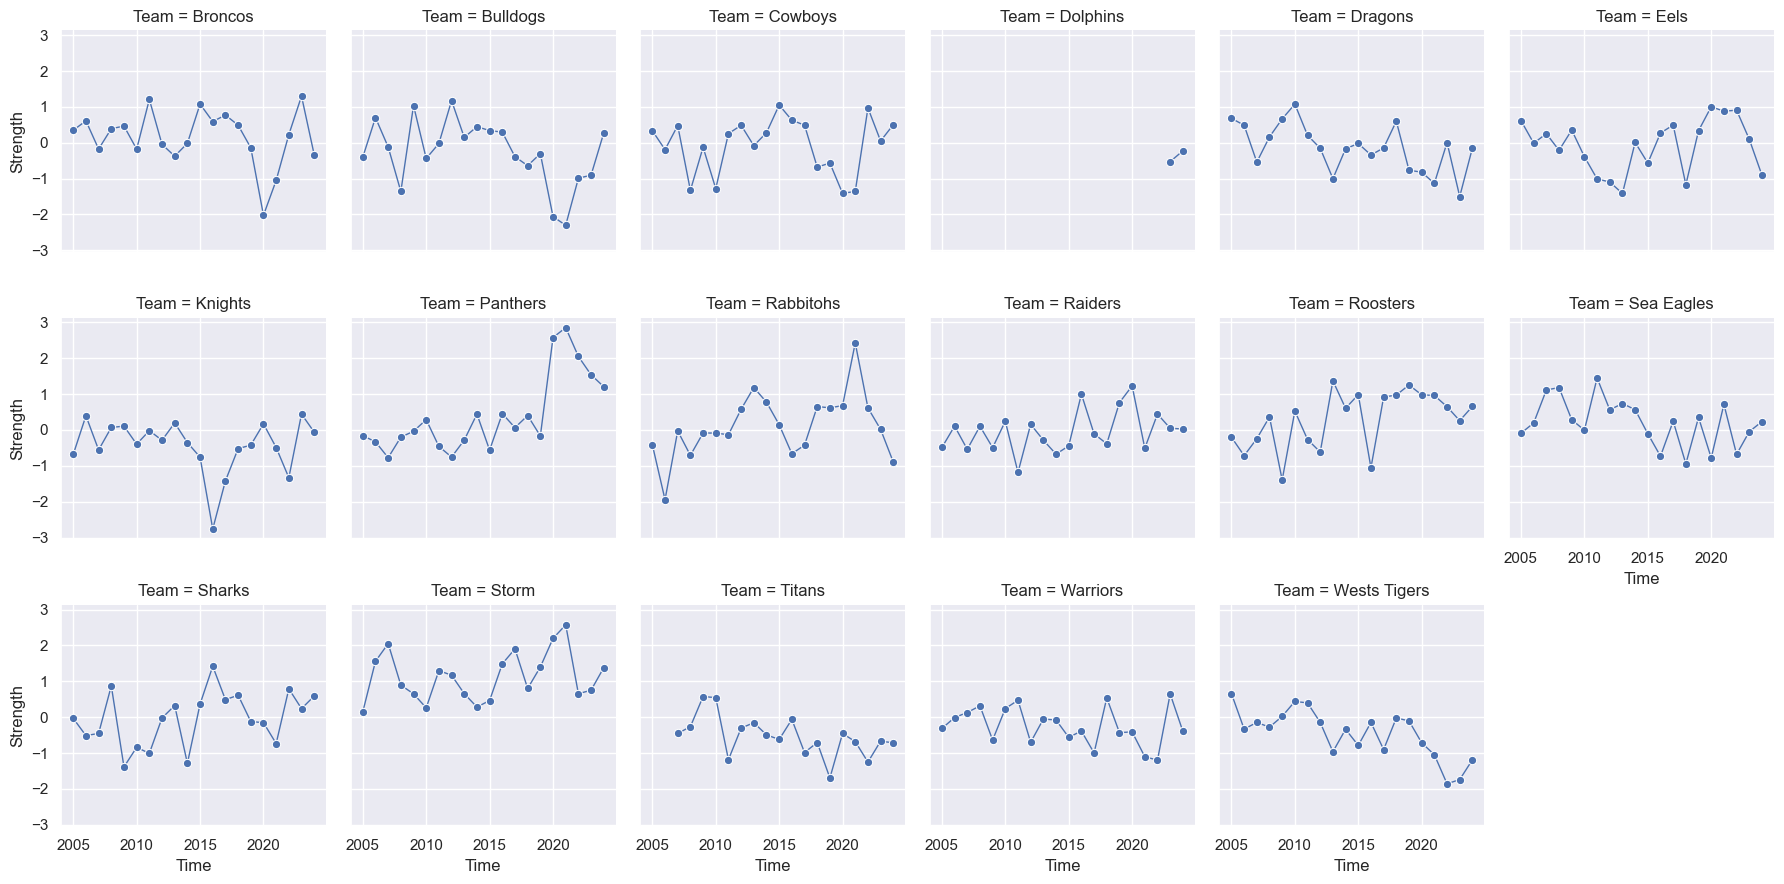

In [25]:
plot_strengths(van, "grid", n_grid_cols = 6)

We also provide some (basic) plotting functionality to help explore things out of the box.
An experienced user is encouraged to adjust or make their own plots for their needs.

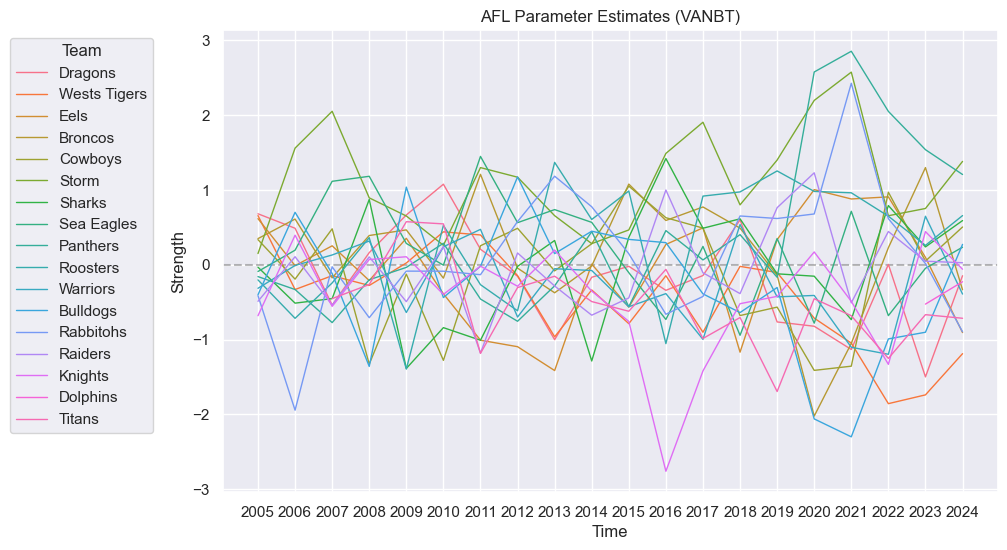

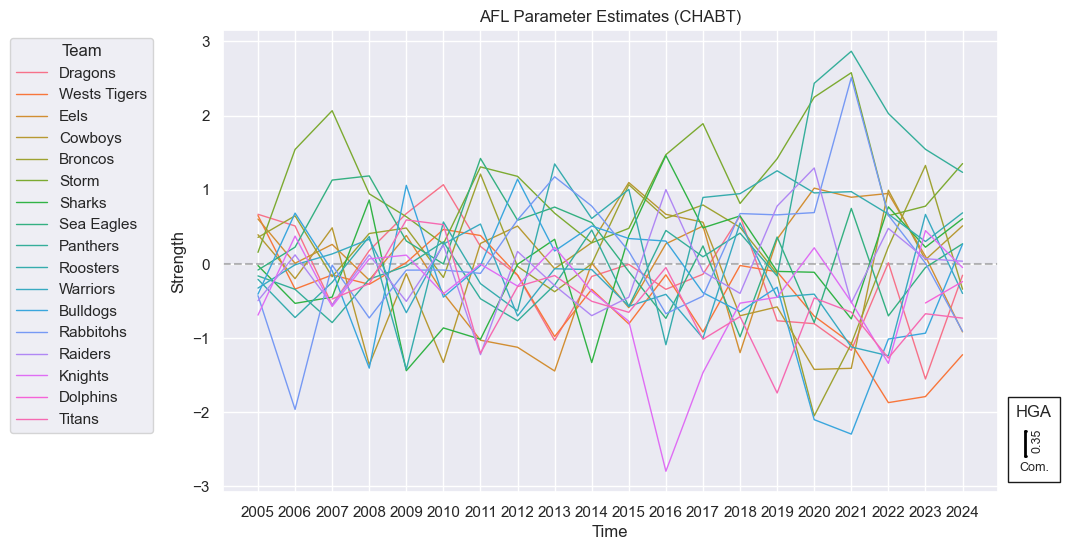

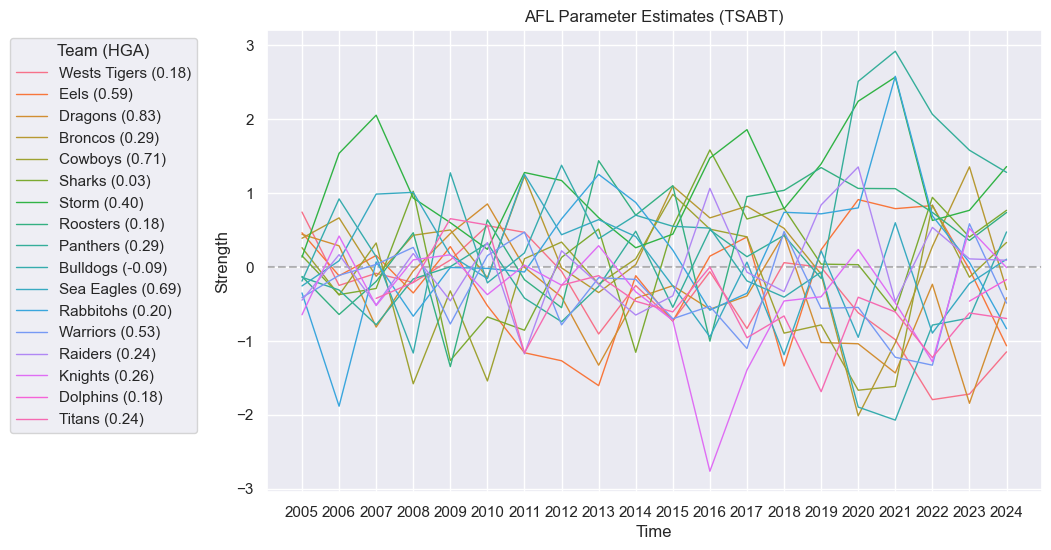

In [26]:
for model in models:
    plt.figure(figsize=(10, 6))
    ax = plot_strengths(model)
    ax = plt.gca()
    sns.move_legend(ax, "upper right", bbox_to_anchor=(-0.08, 1))
    plt.title(f"AFL Parameter Estimates ({model.__class__.__name__})")
    # plt.savefig(f"ch4_nrl_basic_{model.__class__.__name__}", bbox_inches="tight")
    # plt.xticks(rotation=90)
    plt.show()

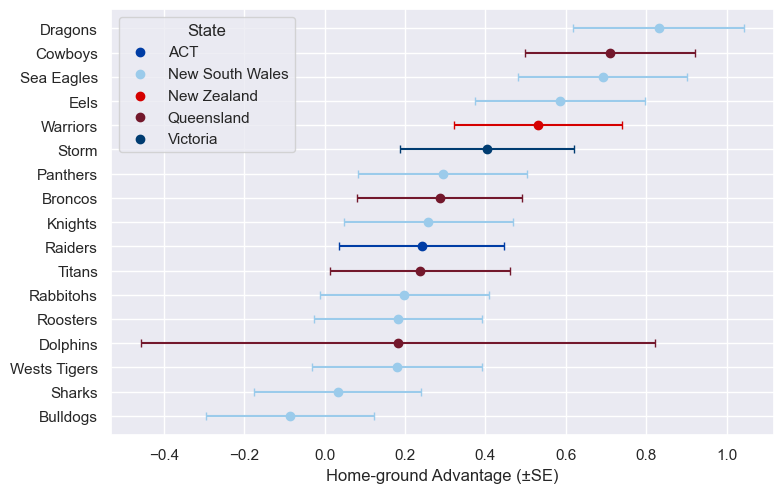

In [27]:
# Make a simple supporting plot to visualise magnitudes of team-specific HGAs
hgas = tsa.get_hgas(include_errors=True).sort_values("HGA", ascending=True)
hgas["State"] = team_locations.state
dummy = hgas.reset_index().rename(columns={"index": "Team"})

states = dummy["State"].unique()

# https://en.wikipedia.org/wiki/Australian_state_and_territory_colours
color_map = {
    'ACT': "#003da5",
    'New South Wales': "#9bcbeb",
    'New Zealand': "#d50000",
    'Queensland': "#73182c",
    # 'South Australia': "#d50032",
    'Victoria': "#003c71",
    # 'Western Australia': "#ffd100"
}

# colors = plt.cm.tab10(range(len(states)))
# color_map = dict(zip(states, colors))

plt.figure(figsize=(8, len(dummy) * 0.3))

for i, row in dummy.iterrows():
    plt.errorbar(
        x=row["HGA"],
        y=i,
        xerr=row["[SE]"],
        fmt="o",
        color=color_map[row["State"]],
        capsize=3
    )

plt.yticks(range(len(dummy)), dummy["Team"])

# legend
for state, color in color_map.items():
    plt.scatter([], [], color=color, label=state)
plt.legend(title="State")

plt.xlabel(f"Home-ground Advantage ({u'\u00b1'}SE)")
plt.tight_layout()
plt.show()

In [28]:
df[df.home == "Dragons"].venue.value_counts()

venue
WIN Stadium                    108
Netstrata Jubilee Stadium       96
Allianz Stadium                 10
ANZ Stadium                     10
Sydney Cricket Ground            7
Accor Stadium                    6
Glen Willow Oval                 2
Suncorp Stadium                  2
Campbelltown Sports Stadium      1
Cbus Super Stadium               1
Toowoomba Sports Ground          1
Browne Park                      1
Name: count, dtype: int64

In [29]:
dummy.HGA.max()

np.float64(0.8309528612044288)

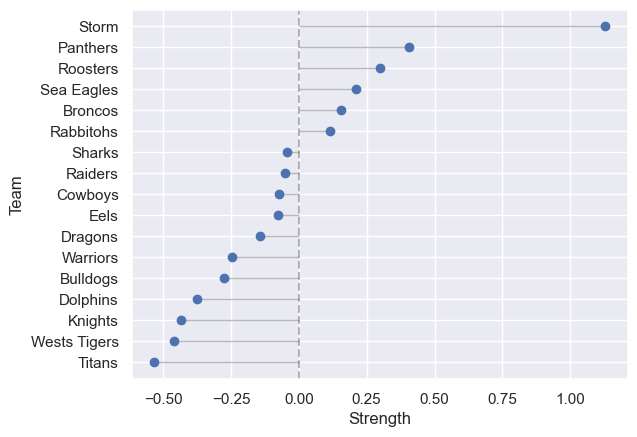

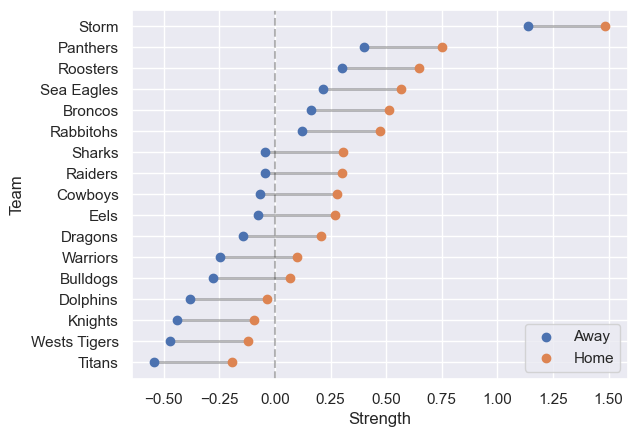

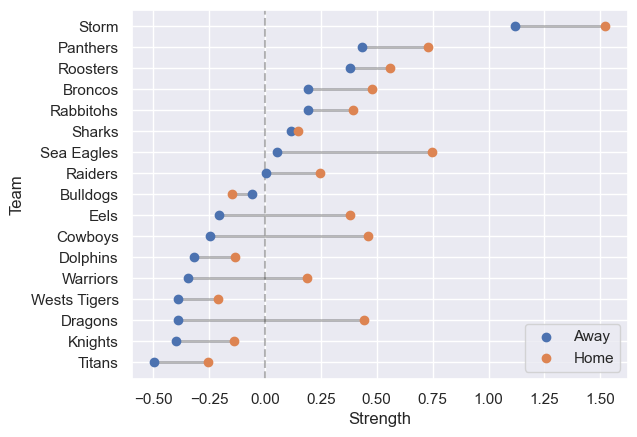

In [30]:
for model in models:
    plot_strengths(model, 'average', mean_centered=True)
    # plt.savefig(f"ch4_nrl_basic_{model.__class__.__name__}_avg", bbox_inches="tight")
    plt.show()

## Hypothesis testing

When models are *nested*, we can compare them by LRT (which becomes a comparison of deviance) and interpretting *p*-values for fit adequacy.
The implementation supports model diagnostics and comparisons.

In [31]:
simple_report(van, cha)
simple_report(cha, tsa)
simple_report(van, tsa)
print()

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      300   2312.33      5224.67      7111.98     
CHABT      301   2265.57      5133.14      7026.74      93.528     4.01e-22 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      301   2265.57      5133.14      7026.74     
TSABT      317   2255.15      5144.30      7138.56      20.844     0.185 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      300   2312.33      5224.67      7111.98     
TSABT      317   2255.15      5144.30      7138.56      114.372    1.81e-16 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



## Hierarchical model fitting

We've looked at some basic models for HGA in AFL and their procedures.
Next, we'd like to analyse some more complex ideas for HGA models.
The hierarchical BT models allow us to specify *relationships* between teams that dictate how HGA exists.

In [19]:
states = team_locations.state.to_dict()

# Generate the relationship matrices for the hierarhical models
teams = list(states.keys())
groups = np.array([states[t] for t in teams])
I = len(teams)

is_vic = (groups == "New South Wales")

In [20]:
## State-wise relationships

# State-specific HGA
# state_specific = team_locations.state.astype("category").cat.codes.to_numpy() + 1
state_specific = team_locations.state.astype("category").to_numpy()
state_specific = state_specific.repeat(I).reshape(I, I)
np.fill_diagonal(state_specific, 0)
state_specific = DataFrame(state_specific, index=teams, columns=teams)


# Within vs across state
# states = team_locations.state.to_numpy()
# same_state  = states[:, None]  == states[None, :]
# matrix = np.where(
#     same_state, 1,
#     2
# )
# np.fill_diagonal(matrix, 0)
# states_sym = DataFrame(matrix, index=teams, columns=teams)

In [101]:
hie_state = HIEBT().fit(basic_hga, state_specific)

In [102]:
dummy = hie_state.get_hgas(include_errors=True).reset_index().rename(columns={"index": "State"})
dummy

,State,HGA,[SE]
0,ACT,0.228316,0.204799
1,New South Wales,0.318561,0.054398
2,New Zealand,0.524115,0.208278
3,Queensland,0.408331,0.113641
4,Victoria,0.405053,0.216712


In [103]:
simple_report(cha, hie_state)
simple_report(hie_state, tsa)
print()

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      301   2265.57      5133.14      7026.74     
HIEBT      305   2264.79      5139.59      7058.36      1.552      0.817 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
HIEBT      305   2264.79      5139.59      7058.36     
TSABT      317   2255.15      5144.30      7138.56      19.292     0.082 .

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



In [104]:
## Sydney vs non-Sydney
cities = team_locations.city.to_dict().values()
is_syd = (np.array([i for i in cities]) == "Sydney")

# 1) Within-vs-across
same_group = is_syd[:, None] == is_syd[None, :]
relmat1 = np.where(same_group, 1, 2)
np.fill_diagonal(relmat1, 0)


# 2) Within-vs-across, split
base = is_syd * 2
same_vic = is_syd[:, None] == is_syd[None, :]
relmat2 = np.where(
    same_vic,
    base[:, None] + 1,
    base[:, None] + 2
)
np.fill_diagonal(relmat2, 0)


# 3) Group-specific: vic vs nonvic
relmat3 = np.where(is_syd[:, None], 1, 2).repeat(I, axis=1)
np.fill_diagonal(relmat3, 0)


relmat1 = DataFrame(relmat1, index=teams, columns=teams)
relmat2 = DataFrame(relmat2, index=teams, columns=teams)
relmat3 = DataFrame(relmat3, index=teams, columns=teams)

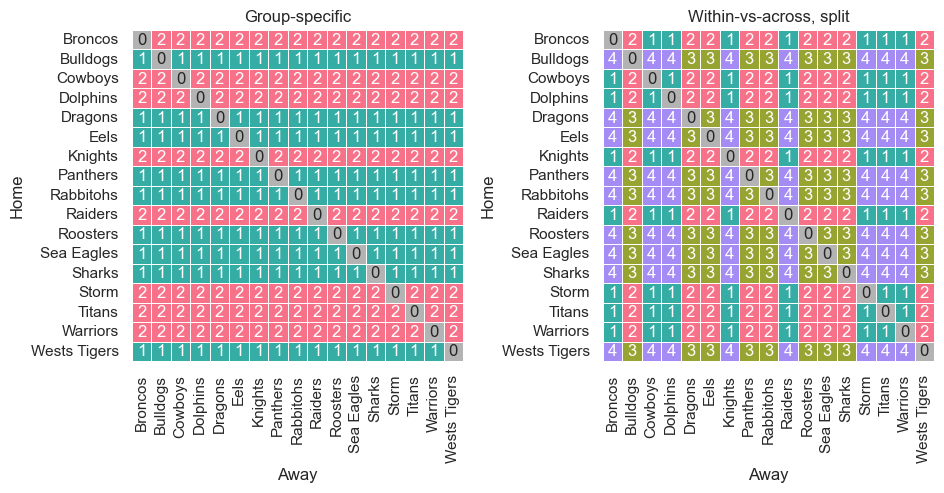

In [127]:
relmats = [relmat3, relmat2]
titles = ["Group-specific", "Within-vs-across, split"]

plot_relmat_grid(relmats, titles, ncols=2, scale=1.2)
plt.show()

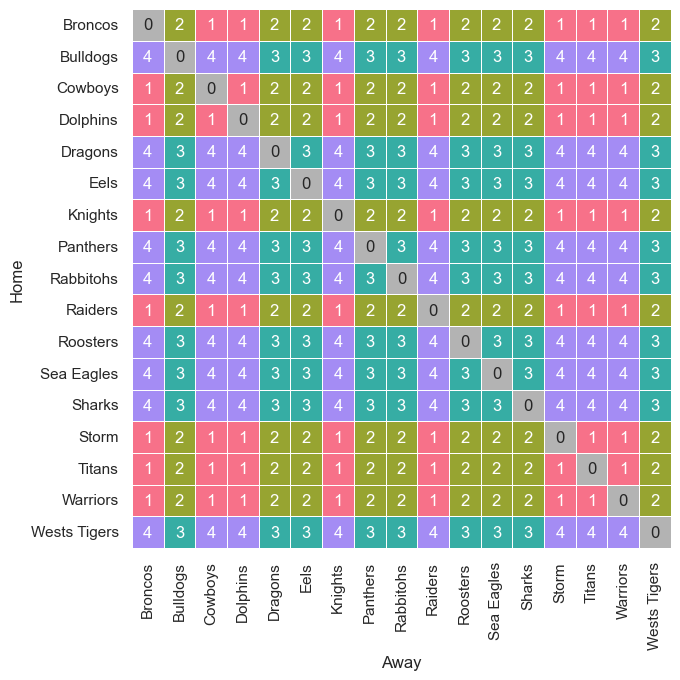

In [106]:
plot_single_relmat(relmat2, (7,7))

The zeroes along the main diagonal are just null values in this case, they get ignored in the model as teams don't play themselves. Using something like `np.nan` would also be fine but converts the other entries to floats which might seem a bit ugly.

In [107]:
# hie3 = HIEBT().fit(basic_hga, relmat1)

In [108]:
hie4 = HIEBT().fit(basic_hga, relmat2)

In [109]:
hie5 = HIEBT().fit(basic_hga, relmat3)

In [110]:
hie4.summary(1)

MODEL SUMMARY: HIEBT

Model Statistics
-------------------------
# Teams:   17              # Obs:     3988
# Times:   20              # Params:  304
LLH:       -2262.742
AIC:       5133.484
BIC:       7045.962
# Iter:    50

Constraint team: Broncos

Team Rankings
-------------------------
Storm           0.971
Panthers        0.394
Roosters        0.296
Sea Eagles      0.216
Rabbitohs       0.122
Broncos         0.000
Sharks         -0.050
Eels           -0.086
Dragons        -0.150
Raiders        -0.215
Cowboys        -0.244
Bulldogs       -0.284
Warriors       -0.421
Wests Tigers   -0.474
Knights        -0.608
Titans         -0.676
Dolphins       -0.889

Home-Ground Advantage
-------------------------
     HGA         [SE]
1  0.489        0.085
2  0.433  2326581.252
3  0.392        0.066
4  0.104  2326581.252



'====================================================================================================\nMODEL SUMMARY: HIEBT\n====================================================================================================\n\nModel Statistics\n-------------------------\n# Teams:   17              # Obs:     3988\n# Times:   20              # Params:  304\nLLH:       -2262.742\nAIC:       5133.484\nBIC:       7045.962\n# Iter:    50\n\nConstraint team: Broncos\n\nTeam Rankings\n-------------------------\nStorm           0.971\nPanthers        0.394\nRoosters        0.296\nSea Eagles      0.216\nRabbitohs       0.122\nBroncos         0.000\nSharks         -0.050\nEels           -0.086\nDragons        -0.150\nRaiders        -0.215\nCowboys        -0.244\nBulldogs       -0.284\nWarriors       -0.421\nWests Tigers   -0.474\nKnights        -0.608\nTitans         -0.676\nDolphins       -0.889\n\nHome-Ground Advantage\n-------------------------\n     HGA         [SE]\n1  0.489        0.085\

In [111]:
hie5.summary(1)

MODEL SUMMARY: HIEBT

Model Statistics
-------------------------
# Teams:   17              # Obs:     3988
# Times:   20              # Params:  302
LLH:       -2265.445
AIC:       5134.889
BIC:       7034.785
# Iter:    47

Constraint team: Broncos

Team Rankings
-------------------------
Storm           0.974
Panthers        0.264
Roosters        0.161
Sea Eagles      0.079
Broncos         0.000
Rabbitohs      -0.015
Sharks         -0.181
Raiders        -0.211
Eels           -0.216
Cowboys        -0.233
Dragons        -0.280
Warriors       -0.413
Bulldogs       -0.417
Knights        -0.606
Wests Tigers   -0.608
Titans         -0.669
Dolphins       -0.879

Home-Ground Advantage
-------------------------
     HGA   [SE]
1  0.325  0.058
2  0.377  0.069



'====================================================================================================\nMODEL SUMMARY: HIEBT\n====================================================================================================\n\nModel Statistics\n-------------------------\n# Teams:   17              # Obs:     3988\n# Times:   20              # Params:  302\nLLH:       -2265.445\nAIC:       5134.889\nBIC:       7034.785\n# Iter:    47\n\nConstraint team: Broncos\n\nTeam Rankings\n-------------------------\nStorm           0.974\nPanthers        0.264\nRoosters        0.161\nSea Eagles      0.079\nBroncos         0.000\nRabbitohs      -0.015\nSharks         -0.181\nRaiders        -0.211\nEels           -0.216\nCowboys        -0.233\nDragons        -0.280\nWarriors       -0.413\nBulldogs       -0.417\nKnights        -0.606\nWests Tigers   -0.608\nTitans         -0.669\nDolphins       -0.879\n\nHome-Ground Advantage\n-------------------------\n     HGA   [SE]\n1  0.325  0.058\n2  0.377  0

<Axes: >

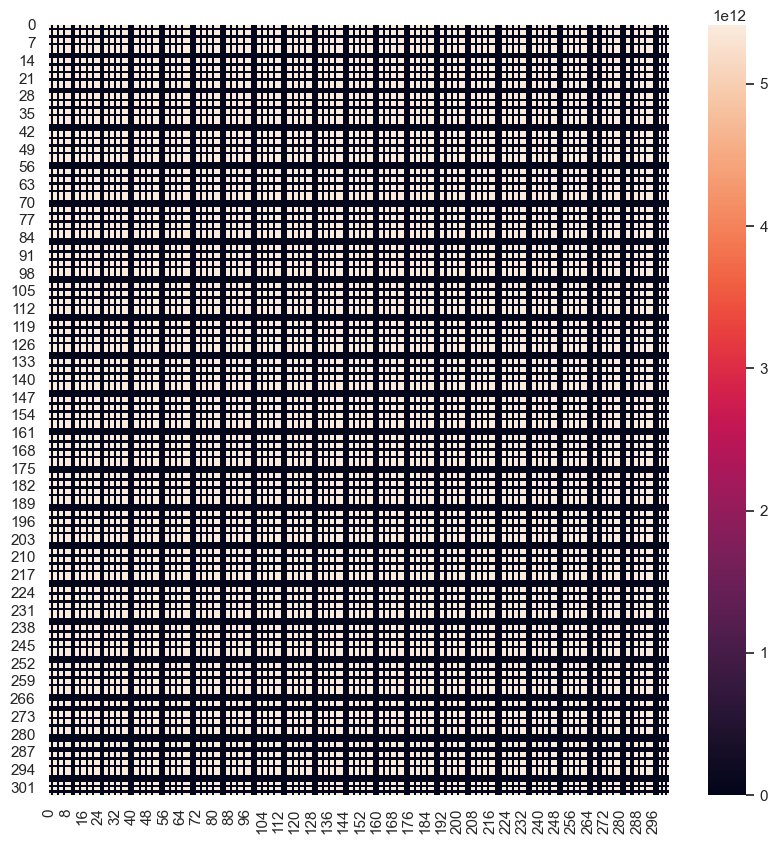

In [112]:
plt.figure(figsize=(10,10))
sns.heatmap(np.abs(hie4._hess_inv - hie4._fit_summary.hess_inv))

In [113]:
est_hess = hie4._fit_summary.hess_inv
est_errs = np.sqrt(np.maximum(np.diag(est_hess), 0))
for idx in sorted(hie4._inactive_idxs):
    est_errs = np.insert(est_errs, idx, np.nan)
hie4.errors = est_errs

In [114]:
hie4.summary(1)

MODEL SUMMARY: HIEBT

Model Statistics
-------------------------
# Teams:   17              # Obs:     3988
# Times:   20              # Params:  304
LLH:       -2262.742
AIC:       5133.484
BIC:       7045.962
# Iter:    50

Constraint team: Broncos

Team Rankings
-------------------------
Storm           0.971
Panthers        0.394
Roosters        0.296
Sea Eagles      0.216
Rabbitohs       0.122
Broncos         0.000
Sharks         -0.050
Eels           -0.086
Dragons        -0.150
Raiders        -0.215
Cowboys        -0.244
Bulldogs       -0.284
Warriors       -0.421
Wests Tigers   -0.474
Knights        -0.608
Titans         -0.676
Dolphins       -0.889

Home-Ground Advantage
-------------------------
     HGA   [SE]
1  0.489  0.079
2  0.433  0.130
3  0.392  0.060
4  0.104  0.131



'====================================================================================================\nMODEL SUMMARY: HIEBT\n====================================================================================================\n\nModel Statistics\n-------------------------\n# Teams:   17              # Obs:     3988\n# Times:   20              # Params:  304\nLLH:       -2262.742\nAIC:       5133.484\nBIC:       7045.962\n# Iter:    50\n\nConstraint team: Broncos\n\nTeam Rankings\n-------------------------\nStorm           0.971\nPanthers        0.394\nRoosters        0.296\nSea Eagles      0.216\nRabbitohs       0.122\nBroncos         0.000\nSharks         -0.050\nEels           -0.086\nDragons        -0.150\nRaiders        -0.215\nCowboys        -0.244\nBulldogs       -0.284\nWarriors       -0.421\nWests Tigers   -0.474\nKnights        -0.608\nTitans         -0.676\nDolphins       -0.889\n\nHome-Ground Advantage\n-------------------------\n     HGA   [SE]\n1  0.489  0.079\n2  0.433  0

In [121]:
hie4.get_hgas(include_errors=True).to_csv("dummy.csv")

We can do hypothesis testing on these models as well by noting that the CHA model is nested in all of them.

In [120]:
simple_report(cha, hie4)
simple_report(cha, hie5)
simple_report(hie5, hie_state)

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      301   2265.57      5133.14      7026.74     
HIEBT      304   2262.74      5133.48      7045.96      5.655      0.130 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      301   2265.57      5133.14      7026.74     
HIEBT      302   2265.44      5134.89      7034.78      0.250      0.617 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
HIEBT      302   2265.44      5134.89      7034.78     
HIEBT      305   2264.79      5139.59      7058.36      NA         NA


{'m1': {'name': 'HIEBT',
  'n_times': 20,
  'aic': np.float64(5134.889307078939),
  'bic': np.float64(7034.784936665621)},
 'm2': {'name': 'HIEBT',
  'n_times': 20,
  'aic': np.float64(5139.587617365628),
  'bic': np.float64(7058.356382345555)},
 'lrt': 'Incompatible'}

## Static and Fully Dynamic Models (previous work)

The main addition of this work compared to previous is the allowance of *dynamic* team strengths (while HGAs are constant).
As such, we are interested in comparing these dynamic models with their static counterparts.

In [50]:
# Testing static models over 3-year windows from 2010-2019

start, end = 2010, 2019
window_length = 3
windows = [(y, y+window_length-1) for y in range(start, end-1)]
results = {}

for w in windows:
    w1, w2 = w

    # Make data
    df_st = df[(w1 <= df.year) & (df.year <= w2)].drop("venue", axis=1)
    # dynamic_van = make_time_blocked_win_matrix(df_st)
    dynamic_hga = make_time_blocked_venue_win_matrices(df_st)

    df_st["time"] = 1
    # static_van = make_time_blocked_win_matrix(df_st)
    static_hga = make_time_blocked_venue_win_matrices(df_st)
    
    # Fit models
    dycha = CHABT().fit(dynamic_hga)
    stcha = CHABT().fit(static_hga)

    results[w] = compare_deviances(stcha, dycha)

In [51]:
# Cleaning up the results for presentation

results_df = (
    DataFrame.from_dict(results, orient="index")
    .rename_axis(["start", "end"])
    .reset_index()
)
results_df["sig"] = results_df["p_value"].apply(
    lambda p: "***" if p <= 0.001 else
              "**"  if p <= 0.01  else
              "*"   if p <= 0.05  else
              "."   if p <= 0.1   else ""
)
results_df.p_value = results_df.p_value.apply(
    lambda p: f"{p:.2e}" if p < 0.001 else f"{p:.3f}"
)
results_df.stat = results_df.stat.round(1)
results_df

,start,end,stat,df,p_value,sig
0,2010,2012,70.6,30,4.02e-05,***
1,2011,2013,59.2,30,0.001,**
2,2012,2014,45.0,30,0.039,*
3,2013,2015,43.3,30,0.055,.
4,2014,2016,75.0,30,1.00e-05,***
5,2015,2017,52.2,30,0.007,**
6,2016,2018,71.5,30,3.02e-05,***
7,2017,2019,55.0,30,0.004,**


In [53]:
# spin up a model for doing manual hypothesis testing

def dummy_model_stats(models: list[BaseBradleyTerry]):
    llh = sum([m._fit_summary.fun for m in models])
    df = sum([m.n_params_active for m in models])
    return llh, df

def quick_comparison(dynamics, static):
    dyllh, dydf = dummy_model_stats(dynamics)
    D_value = calculate_deviance_test_stat(static._fit_summary.fun, dyllh)
    df = dydf - static.n_params_active

    if df <= 0:
        raise ValueError("Model M1 must have less parameters than M2.")

    p_val = chi2.sf(D_value, df)
    p_val_text = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

    print(f"D={D_value:.3f} on {df} df, p={p_val_text}")

In [56]:
dummy = df[(start <= df.year) & (df.year <= end)].drop("venue", axis=1)
dummy

,home,away,home_score,away_score,is_neutral,year
981,Eels,Dragons,12.0,18.0,0,2010
982,Broncos,Cowboys,30.0,24.0,0,2010
983,Bulldogs,Knights,16.0,20.0,0,2010
984,Panthers,Raiders,34.0,16.0,0,2010
985,Sharks,Storm,10.0,14.0,0,2010
...,...,...,...,...,...,...
2986,Rabbitohs,Sea Eagles,34.0,26.0,0,2019
2987,Storm,Eels,32.0,0.0,0,2019
2988,Raiders,Rabbitohs,16.0,10.0,0,2019
2989,Roosters,Storm,14.0,6.0,0,2019


In [57]:
# Testing home-ground advantage as well
fully_dycha = []
for y in range(start, end+1):
    df_full = df[df.year == y].drop("venue", axis=1)
    # dynamic_van = make_time_blocked_win_matrix(df_st)
    dynamic_hga = make_time_blocked_venue_win_matrices(df_full)
    m = CHABT().fit(dynamic_hga)
    fully_dycha.append(m)

dycha2 = CHABT().fit(make_time_blocked_venue_win_matrices(dummy))

In [58]:
quick_comparison(fully_dycha, dycha2)

D=6.221 on 9 df, p=0.718


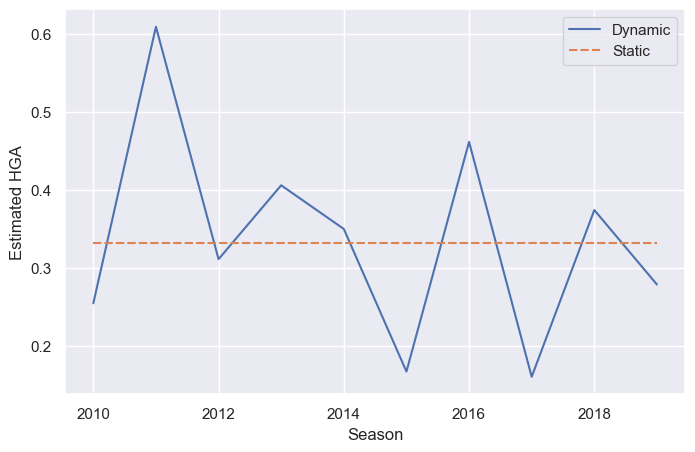

In [61]:
dummy_hgas = {m.times[0]: m.get_param("hga") for m in fully_dycha}
# for m in fully_dycha: m.get_hgas()
dummy_hgas = DataFrame.from_dict(dummy_hgas, orient="index", columns=["Dynamic"])
dummy_hgas["Static"] = dycha2.get_param("hga")

plt.figure(figsize=(8, 5))
sns.lineplot(dummy_hgas)
plt.xlabel("Season")
plt.ylabel("Estimated HGA")
plt.show()

In [59]:
# Testing home-ground advantage as well
fully_dytsa = []
for y in range(start, end+1):
    df_full = df[df.year == y].drop("venue", axis=1)
    # dynamic_van = make_time_blocked_win_matrix(df_st)
    dynamic_hga = make_time_blocked_venue_win_matrices(df_full)
    m = TSABT().fit(dynamic_hga)
    fully_dytsa.append(m)

dytsa2 = TSABT().fit(make_time_blocked_venue_win_matrices(dummy))

In [60]:
quick_comparison(fully_dytsa, dytsa2)

D=167.794 on 144 df, p=0.085


## Case study: COVID-19

We're interested in analysing the years shortly before and after the COVID-19 pandemic to see if HGA changed significantly over this period.
Many changes were implemented into the competition due to lockdowns, such as cancelling games, moving matches to other venues, and employing "ghost games" where fans are not present.

In [23]:
# Baseline with vanilla models
covid_before_van = {i: df_van[i] for i in range(2017, 2020)}
covid_during_van = {i: df_van[i] for i in range(2020, 2022)}
covid_after_van = {i: df_van[i] for i in range(2022, 2025)}

covid_not_during_van = covid_before_van | covid_after_van
covid_all_van = covid_not_during_van | covid_during_van

van_covid_before = VANBT().fit(covid_before_van)
van_covid_during = VANBT().fit(covid_during_van)
van_covid_after = VANBT().fit(covid_after_van)

van_covid_static = VANBT().fit(covid_not_during_van)
van_covid_all = VANBT().fit(covid_all_van)

In [24]:
# Make our windows of data to examine
covid_before = {i: df_cha[i] for i in range(2017, 2020)}
covid_during = {i: df_cha[i] for i in range(2020, 2022)}
covid_after = {i: df_cha[i] for i in range(2022, 2025)}

covid_not_during = covid_before | covid_after
covid_all = covid_not_during | covid_during

In [25]:
# Common HGA
cha_covid_before = CHABT().fit(covid_before)
cha_covid_during = CHABT().fit(covid_during)
cha_covid_after = CHABT().fit(covid_after)

cha_covid_static = CHABT().fit(covid_not_during)
cha_covid_all = CHABT().fit(covid_all)

In [27]:
# Team-specific HGA
tsa_covid_before = TSABT().fit(covid_before)
tsa_covid_during = TSABT().fit(covid_during)
tsa_covid_after = TSABT().fit(covid_after)

# Compared to models just assuming it's constant
tsa_covid_static = TSABT().fit(covid_not_during)
tsa_covid_all = TSABT().fit(covid_all)

In [28]:
# State-specific HGA
ssa_covid_before = HIEBT().fit(covid_before, state_specific)
ssa_covid_during = HIEBT().fit(covid_during, state_specific)
ssa_covid_after = HIEBT().fit(covid_after, state_specific)

# Compared to models just assuming it's constant
ssa_covid_static = HIEBT().fit(covid_not_during, state_specific)
ssa_covid_all = HIEBT().fit(covid_all, state_specific)

In [29]:
_ = simple_report(van_covid_all, cha_covid_all)
_ = simple_report(van_covid_static, cha_covid_static)

_ = simple_report(cha_covid_all, ssa_covid_all)
_ = simple_report(cha_covid_static, ssa_covid_static)

_ = simple_report(cha_covid_all, tsa_covid_all)
_ = simple_report(cha_covid_static, tsa_covid_static)

Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      122   874.44       1992.87      2648.96     
CHABT      123   860.88       1967.76      2629.23      27.112     1.92e-07 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
VANBT      92    705.80       1595.60      2066.16     
CHABT      93    693.03       1572.06      2047.73      25.542     4.33e-07 ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Terry Model Comparison
------------------------------

Model      df    NLL          AIC          BIC          Deviance   p
CHABT      123   860.88       1967.76      2629.23     
HIEBT      127   858.47       1970.94      2653.91      4.826      0.306 

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Bradley-Te

In [30]:
quick_comparison((cha_covid_static, cha_covid_during), cha_covid_all)
quick_comparison((ssa_covid_static, ssa_covid_during), ssa_covid_all)
quick_comparison((tsa_covid_static, tsa_covid_during), tsa_covid_all)

D=0.679 on 1 df, p=0.410
D=9.061 on 5 df, p=0.107
D=20.774 on 17 df, p=0.237


In [31]:
# Testing - need to do it manually because models are separated

quick_comparison((cha_covid_before, cha_covid_during, cha_covid_after), cha_covid_all)
quick_comparison((cha_covid_before, cha_covid_after), cha_covid_static)

quick_comparison((ssa_covid_before, ssa_covid_during, ssa_covid_after), ssa_covid_all)
quick_comparison((ssa_covid_before, ssa_covid_after), ssa_covid_static)

quick_comparison((tsa_covid_before, tsa_covid_during, tsa_covid_after), tsa_covid_all)
quick_comparison((tsa_covid_before, tsa_covid_after), tsa_covid_static)


D=1.449 on 2 df, p=0.484
D=0.770 on 1 df, p=0.380
D=11.536 on 10 df, p=0.317
D=2.475 on 5 df, p=0.780
D=33.348 on 34 df, p=0.499
D=12.574 on 17 df, p=0.764


In [32]:
print(cha_covid_before.get_hgas("hga").round(3))
print(cha_covid_during.get_hgas("hga").round(3))
print(cha_covid_after.get_hgas("hga").round(3))

print(cha_covid_static.get_hgas("hga").round(3))
print(cha_covid_all.get_hgas("hga").round(3))

          HGA   [SE]
Common  0.273  0.092
          HGA   [SE]
Common  0.204  0.137
          HGA   [SE]
Common  0.388  0.094
         HGA   [SE]
Common  0.33  0.066
          HGA   [SE]
Common  0.306  0.059


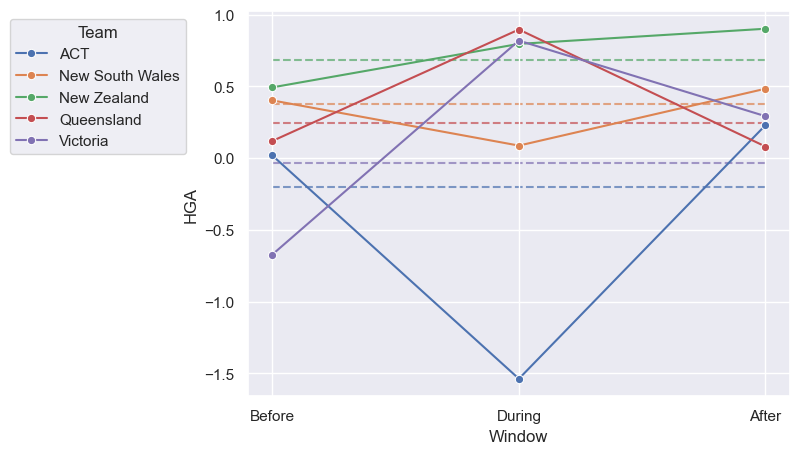

In [33]:
models = (ssa_covid_before, ssa_covid_during, ssa_covid_after)
combined = pd.concat(
    [mod.get_hgas()["HGA"] for mod in models],
    axis=1
)

combined.columns = ["Before", "During", "After"]

long = (
    combined
    .reset_index()                 # bring team out of index
    .rename(columns={"index": "Team"})
    .melt(id_vars="Team", var_name="Window", value_name="HGA")
)

hga_all = ssa_covid_all.get_hgas()["HGA"]
ref = (
    pd.concat([hga_all]*len(combined.columns), axis=1)
    .set_axis(combined.columns, axis=1)
    .reset_index()
    .rename(columns={"index": "Team"})
    .melt(id_vars="Team", var_name="Window", value_name="HGA")
)

plt.figure(figsize=(7, 5))
ax = sns.lineplot(
    data=long,
    x="Window",
    y="HGA",
    hue="Team",
    marker="o"
)
sns.lineplot(
    data=ref,
    x="Window",
    y="HGA",
    hue="Team",
    linestyle="--",
    legend=False,   # avoid duplicate legend
    zorder=-1,
    alpha=0.7,
    ax=ax
)
sns.move_legend(ax, "upper right", bbox_to_anchor=(-0.1, 1))
plt.show()

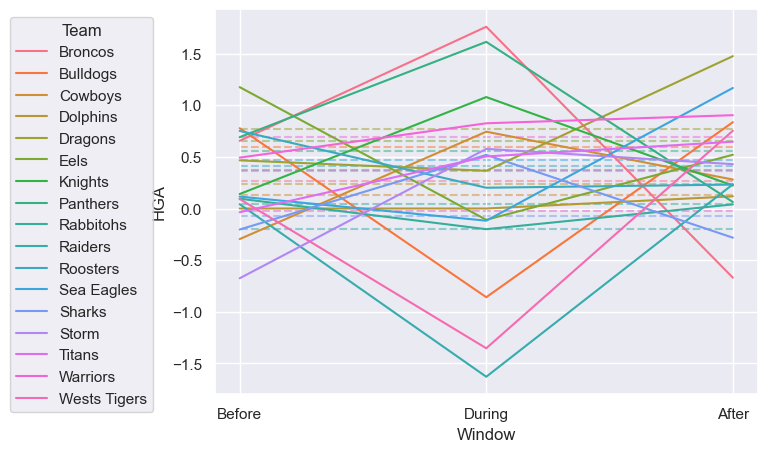

In [34]:
models = (tsa_covid_before, tsa_covid_during, tsa_covid_after)
combined = pd.concat(
    [mod.get_hgas()["HGA"] for mod in models],
    axis=1
)

combined.columns = ["Before", "During", "After"]

long = (
    combined
    .reset_index()                 # bring team out of index
    .rename(columns={"index": "Team"})
    .melt(id_vars="Team", var_name="Window", value_name="HGA")
)

hga_all = tsa_covid_all.get_hgas()["HGA"]
ref = (
    pd.concat([hga_all]*len(combined.columns), axis=1)
    .set_axis(combined.columns, axis=1)
    .reset_index()
    .rename(columns={"index": "Team"})
    .melt(id_vars="Team", var_name="Window", value_name="HGA")
)

plt.figure(figsize=(7, 5))
ax = sns.lineplot(
    data=long,
    x="Window",
    y="HGA",
    hue="Team",
    # marker="o"
)
sns.lineplot(
    data=ref,
    x="Window",
    y="HGA",
    hue="Team",
    linestyle="--",
    legend=False,   # avoid duplicate legend
    zorder=-1,
    alpha=0.5,
    ax=ax
)
sns.move_legend(ax, "upper right", bbox_to_anchor=(-0.1, 1))
plt.show()

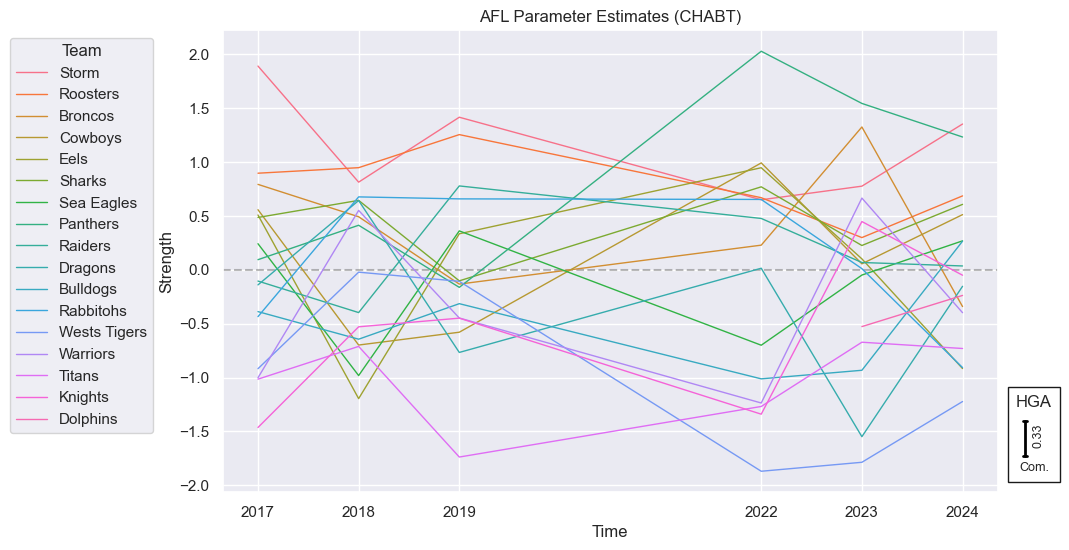

In [35]:
plt.figure(figsize=(10, 6))
ax = plot_strengths(cha_covid_static)
ax = plt.gca()
sns.move_legend(ax, "upper right", bbox_to_anchor=(-0.08, 1))
plt.title(f"AFL Parameter Estimates ({cha_covid_static.__class__.__name__})")
# plt.savefig(f"ch4_afl_basic_{model.__class__.__name__}", bbox_inches="tight")
# plt.xticks(rotation=90)
plt.show()